In [1]:
import numpy as np
print(np.__version__)

2.2.6


In [2]:
import sys
import os
sys.path.append(os.path.abspath('../'))

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

from tqdm import tqdm

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.validation import get_tpcf

### Helpers and Functions

In [3]:
#### Calculate 2pcf for sampled
def calc_tpcf_gen(gen_array, scale=True):
    """
    gen array must have size: # cosmology, # repeats, # particles, 3
    """
    gen_tpcf = []
    for i in tqdm(range(gen_array.shape[0])):
        inter_gen_tpcf = []
        for j in range(gen_array[i].shape[0]):
            if scale:
                inter_gen_tpcf.append(get_tpcf(gen_array[i][j] * 370, boxsize, r_bins, mu_bins))
            else:
                inter_gen_tpcf.append(get_tpcf(gen_array[i][j], boxsize, r_bins, mu_bins))
        gen_tpcf.append(np.array(inter_gen_tpcf))
    gen_tpcf = np.array(gen_tpcf)

    return gen_tpcf

In [4]:
#### Calculate 2pcf for simulated
def calc_tpcf_true(true_array, scale=True):
    sim_tpcf = []
    for i in tqdm(range(true_array.shape[0])):
        if scale:
            sim_tpcf.append(get_tpcf(true_array[i] * 370, boxsize, r_bins, mu_bins))
        else:
            sim_tpcf.append(get_tpcf(true_array[i], boxsize, r_bins, mu_bins))
    sim_tpcf = np.array(sim_tpcf)

    return sim_tpcf

In [5]:
#### Calculate MAE
def calc_mae(sim_tpcf, gen_tpcf):
    
    mae = np.mean(np.absolute(sim_tpcf[:, None] - gen_tpcf), axis=(0, 1))
    mae_total = np.mean(mae)
    
    print(f'''
    MAE:", {mae}
    
    AVG MAE:", {mae_total}''')

    return mae, mae_total

In [6]:
#### Calculate MSE 
def calc_mse(sim_tpcf, gen_tpcf):
    mse = np.mean((sim_tpcf[:, None] - gen_tpcf)**2, axis=(0, 1))
    mse_total = np.mean(mse)
    print(f'''
    MSE:", {mse}
    
    AVG MSE:", {mse_total}''')

    return mse, mse_total

### Data Loading and Preprocessing

In [7]:
# Two-Point Correlation function
boxsize = 370.
r_bins = np.linspace(0.5, 150.0, 25) # Defines 25 linearly spaced bins from 0.5 to 150 for the radial separation r
r_c = 0.5*(r_bins[1:] + r_bins[:-1]) # Computes the center of each radial bin (midpoint between two consecutive bins)
mu_bins = np.linspace(-1, 1, 201)

In [8]:
# Generated samples
train_run = "20260508_154857"
infer_run = "20260510_152628"
gen_samples = torch.load(f"/gpfs/home4/bartb/T256/T256-SUBBOX/results/run_{train_run}/quantitative_2pcf/{infer_run}/gen_samples.pth", weights_only=False)
# print(f"Shape of generated samples: {gen_samples.shape}")

# batches, batch_size, repeats, halos, D = gen_samples.shape[0], gen_samples.shape[1], gen_samples.shape[2], gen_samples.shape[3], gen_samples.shape[4]
# gen_samples = gen_samples.reshape(batches*batch_size, repeats, halos, D)
params = torch.load(f"/gpfs/home4/bartb/T256/T256-SUBBOX/results/run_{train_run}/quantitative_2pcf/{infer_run}/cond.pth", weights_only=False)
# print(f"Shape of generated samples: {gen_samples.shape}")
# print(f"Shape of parameter tensor: {params.shape}")
# print(gen_samples[0][0])

In [9]:
# True validation samples
true_samples = torch.from_numpy(np.load("/gpfs/home4/bartb/T256/Data/subboxes/test_subbox_halos.npy")[..., :3])
halo_counts = np.load("/gpfs/home4/bartb/T256/Data/subboxes/test_subbox_counts.npy")
params = pd.read_csv("/gpfs/home4/bartb/T256/Data/subboxes/test_cosmology.csv").values

print(f"true_samples: {true_samples.shape}")
print(f"halo_counts: {halo_counts.shape}")
print(f"params: {params.shape}")

true_samples: torch.Size([1887, 320, 3])
halo_counts: (1887,)
params: (1887, 5)


In [10]:
cosm_tol = 1e-4
unique_cosms = []
subbox_indices_per_cosm = []

for i in range(params.shape[0]):
    cosm = params[i]
    # Check if we've already seen this cosmology
    found = False
    for j, uc in enumerate(unique_cosms):
        if np.all(np.abs(cosm - uc) < cosm_tol):
            subbox_indices_per_cosm[j].append(i)
            found = True
            break
    if not found:
        unique_cosms.append(cosm)
        subbox_indices_per_cosm.append([i])

unique_cosms = np.array(unique_cosms)
n_cosms = len(unique_cosms)
print(f"Found {n_cosms} unique cosmologies from {params.shape[0]} subboxes")
print(f"Subboxes per cosmology: {[len(x) for x in subbox_indices_per_cosm]}")

Found 200 unique cosmologies from 1887 subboxes
Subboxes per cosmology: [9, 10, 10, 10, 10, 9, 10, 10, 10, 10, 10, 10, 9, 10, 10, 10, 10, 10, 10, 10, 6, 10, 9, 7, 10, 10, 3, 10, 10, 10, 10, 4, 6, 10, 10, 10, 8, 10, 10, 10, 10, 8, 10, 10, 10, 9, 10, 10, 10, 10, 9, 10, 10, 10, 6, 10, 10, 10, 10, 10, 9, 10, 10, 8, 10, 10, 10, 10, 8, 10, 5, 10, 10, 10, 7, 10, 10, 5, 10, 10, 10, 10, 10, 10, 6, 10, 10, 8, 7, 10, 10, 6, 9, 10, 10, 10, 10, 1, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 8, 10, 10, 10, 10, 9, 10, 10, 10, 10, 10, 10, 8, 10, 10, 10, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 10, 4, 8, 10, 10, 8, 10, 10, 7, 10, 10, 10, 7, 9, 10, 10, 10, 10, 10, 9, 10, 10, 9, 10, 10, 10, 10, 10, 10, 10, 9, 10, 10, 7, 10, 10, 10, 10, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 8, 10, 9, 10, 10]


In [11]:
tpcf_true_avg = []
tpcf_true_std = []

for i in tqdm(range(n_cosms)):
    indices = subbox_indices_per_cosm[i]
    tpcfs = []
    for idx in indices:
        n_h = halo_counts[idx]
        sample = true_samples[idx, :n_h, :3].numpy()
        tpcf = get_tpcf(sample, boxsize, r_bins, mu_bins)
        tpcfs.append(tpcf)
    tpcfs = np.array(tpcfs)
    tpcf_true_avg.append(np.mean(tpcfs, axis=0))
    tpcf_true_std.append(np.std(tpcfs, axis=0))

tpcf_true_avg = np.array(tpcf_true_avg)  # (n_cosms, n_rbins)
tpcf_true_std = np.array(tpcf_true_std)
print(f"Averaged GT 2PCF shape: {tpcf_true_avg.shape}")

  0%|          | 0/200 [00:00<?, ?it/s]/home/bartb/venvs/boids/lib/python3.11/site-packages/pycorr/corrfunc.py:153: UserWarning: These arguments are not read: {'n_threads': 2}
  warnings.warn('These arguments are not read: {}'.format(attrs))
100%|██████████| 200/200 [00:11<00:00, 17.02it/s]

Averaged GT 2PCF shape: (200, 24)


In [12]:
# n_repeats = config["inference"]["n_repeats"]
n_repeats = 20

tpcf_gen = []
for i in tqdm(range(len(gen_samples))):
    samples = gen_samples[i].squeeze(0)
    tpcfs = []
    for j in range(samples.shape[0]):
        tpcfs.append(get_tpcf(samples[j] * 370, boxsize, r_bins, mu_bins))
    tpcf_gen.append(np.array(tpcfs))
tpcf_gen = np.array(tpcf_gen)
print(f"Generated 2PCF shape: {tpcf_gen.shape}")

100%|██████████| 1887/1887 [01:57<00:00, 16.06it/s]

Generated 2PCF shape: (1887, 10, 24)


In [13]:
tpcf_gen_avg = []
for i in range(n_cosms):
    indices = subbox_indices_per_cosm[i]
    # tpcf_gen[indices] gives all generated 2PCFs for subboxes with this cosmology
    # Average over subboxes, keep repeats
    gen_for_cosm = tpcf_gen[indices]  # (n_subboxes, n_repeats, 24)
    # Reshape to pool all repeats across subboxes
    pooled = gen_for_cosm.reshape(-1, 24)  # (n_subboxes * n_repeats, 24)
    tpcf_gen_avg.append(pooled)

In [14]:
mae_total = np.mean([np.mean(np.abs(tpcf_true_avg[i] - tpcf_gen_avg[i])) for i in range(n_cosms)])
mse_total = np.mean([np.mean((tpcf_true_avg[i] - tpcf_gen_avg[i])**2) for i in range(n_cosms)])
print(f"MAE: {mae_total:.4f}")
print(f"MSE: {mse_total:.4f}")

MAE: 0.3142
MSE: 1.2578


In [15]:
# # Calculate MSE and MAE
# mae, mae_total = calc_mae(tpcf_true_avg, tpcf_gen)
# mse, mse_total = calc_mse(tpcf_true_avg, tpcf_gen)

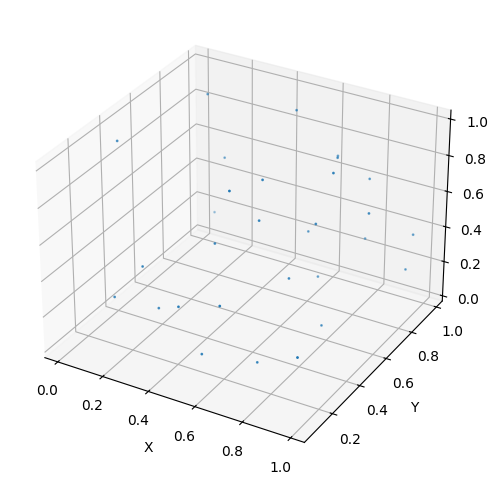

In [16]:
# Visualization of a generated sample
halos = gen_samples[50][0]
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")


ax.scatter(halos[:, 0], halos[:, 1], halos[:, 2], s=1)


ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")


plt.show()


torch.Size([320, 3])


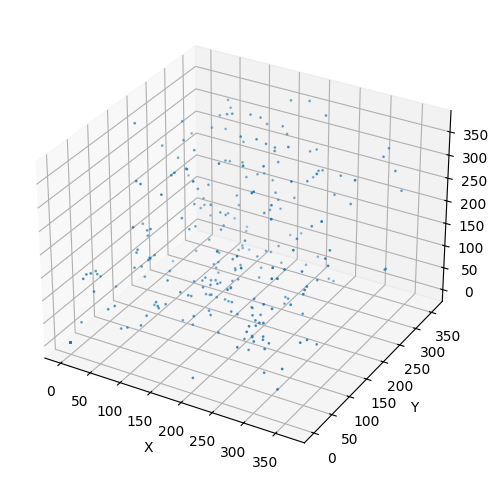

In [17]:
# Visualization of a true sample
halos = true_samples[50]
print(halos.shape)
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")


ax.scatter(halos[:, 0], halos[:, 1], halos[:, 2], s=1)


ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")


plt.show()


In [18]:
sample = torch.rand(5, 5).repeat_interleave(20, dim=0)
batch = torch.arange(0, 100).repeat_interleave(5000, dim=0)
sample[batch]

tensor([[0.5521, 0.4168, 0.0012, 0.7165, 0.6104],
        [0.5521, 0.4168, 0.0012, 0.7165, 0.6104],
        [0.5521, 0.4168, 0.0012, 0.7165, 0.6104],
        ...,
        [0.8143, 0.8516, 0.8999, 0.6354, 0.8799],
        [0.8143, 0.8516, 0.8999, 0.6354, 0.8799],
        [0.8143, 0.8516, 0.8999, 0.6354, 0.8799]])